<a href="https://colab.research.google.com/github/nawroz-m/ML_learning/blob/main/food_vision.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Food Vision

## Check the GPU
Google Colab offer free GPU, however not all of them are compatible with `mixed precision training`

[Google Colab offers](https://developer.nvidia.com/cuda-gpus):

* K80(not compatible)
* P100(not compatible)
* Tesla T4(compatible)

In [3]:
!nvidia-smi -L

GPU 0: Tesla T4 (UUID: GPU-5952a437-5ff6-cb4f-20df-29aa2dd81b6b)


## Use TensorFlow Dataset to download data

In [4]:
import tensorflow_datasets as tfds
from tensorflow.keras import mixed_precision
import tensorflow as tf
import matplotlib.pyplot as plt
import datetime
import os
import random

In [5]:
# list the available dataset
dataset_list = tfds.list_builders()
print('food101' in dataset_list) # it's a very long list so just check if your dataset is exist

True


In [ ]:
# load the dataset
(train_data, test_data), ds_info = tfds.load(name='food101',
                                             split=['train', 'validation'],
                                             as_supervised= True, # data get return in key value per(Tuple)
                                             shuffle_files=True,
                                             with_info=True)

# Exploring the food1001 data from TensorFlow Datasets
To become one with our data we want to find:
* Class names
* The shape of our input data (image tensore)
* The data type of our input data
* What the labels look like(e.g. are they one-hot encoded or are they label encoded)
* Do the label mutch up with the class names?

In [7]:
# Feature of food101 from TFDS
ds_info.features

FeaturesDict({
    'image': Image(shape=(None, None, 3), dtype=uint8),
    'label': ClassLabel(shape=(), dtype=int64, num_classes=101),
})

In [8]:
# Get the class names
class_names = ds_info.features['label'].names
class_names[:10]

['apple_pie',
 'baby_back_ribs',
 'baklava',
 'beef_carpaccio',
 'beef_tartare',
 'beet_salad',
 'beignets',
 'bibimbap',
 'bread_pudding',
 'breakfast_burrito']

In [9]:
train_data

<_PrefetchDataset element_spec=(TensorSpec(shape=(None, None, 3), dtype=tf.uint8, name=None), TensorSpec(shape=(), dtype=tf.int64, name=None))>

In [10]:
# Take one sample of the train data
train_one_sample = train_data.take(1) # samples are in the form of (image_tensor, label)
# What does one sample of our training data looks like
train_one_sample

<_TakeDataset element_spec=(TensorSpec(shape=(None, None, 3), dtype=tf.uint8, name=None), TensorSpec(shape=(), dtype=tf.int64, name=None))>

In [11]:
# Output info about our training data
for image, label in train_one_sample:
  print(f"""
        Image shape: {image.shape}
        Image datatype: {image.dtype}
        Target classe from food100(tensor form): {label}
        Class name(str form):  {class_names[label.numpy()]}
  """)


        Image shape: (384, 512, 3)
        Image datatype: <dtype: 'uint8'>
        Target classe from food100(tensor form): 97
        Class name(str form):  takoyaki
  


In [12]:
# What does our image data from TFDS looks like?
image

<tf.Tensor: shape=(384, 512, 3), dtype=uint8, numpy=
array([[[ 54,  30,  26],
        [ 57,  33,  29],
        [ 72,  49,  43],
        ...,
        [192, 184, 163],
        [190, 179, 159],
        [181, 169, 147]],

       [[ 51,  28,  22],
        [ 60,  37,  31],
        [ 81,  58,  52],
        ...,
        [191, 183, 162],
        [189, 176, 157],
        [176, 164, 142]],

       [[ 78,  58,  49],
        [ 96,  76,  67],
        [122, 102,  93],
        ...,
        [191, 183, 162],
        [188, 175, 156],
        [172, 157, 136]],

       ...,

       [[162, 140, 117],
        [164, 142, 119],
        [169, 147, 126],
        ...,
        [  5,   5,   5],
        [  6,   6,   6],
        [  6,   6,   6]],

       [[168, 146, 123],
        [170, 148, 125],
        [176, 154, 131],
        ...,
        [  5,   5,   5],
        [  6,   6,   6],
        [  6,   6,   6]],

       [[173, 151, 128],
        [176, 154, 131],
        [182, 160, 137],
        ...,
        [  4,   4,   

In [13]:
# What are the min and max values of our image tensor?
tf.reduce_min(image), tf.reduce_max(image)

(<tf.Tensor: shape=(), dtype=uint8, numpy=0>,
 <tf.Tensor: shape=(), dtype=uint8, numpy=255>)

## Plot an image form Tensorflow Dataset

(np.float64(-0.5), np.float64(511.5), np.float64(383.5), np.float64(-0.5))

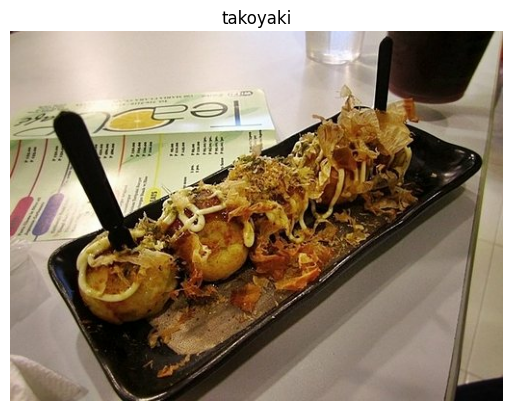

In [14]:
# Plot an image
plt.imshow(image)
plt.title(class_names[label.numpy()])
plt.axis(False)

## Preprocess the data
Neural Network work best when the data is in certain way. e.g (Normalized, batched, and etc). However not all data including `Tensorflow Dataset` comes like this.

What we know about our data:
* It's in `unit8`
* Comprised of all diffirent size tensors (diffirent size of images)
* It's not scaled, the pixel values are between 0 and 255
What a model like:
* Data in `float32` dtype(or for mixed percision `float16` and `float32`)
* For `batches`, Tensorflow likes all of the tensors within a batch to be of the same size
* `Scaled`(Values between 0 and 1) also called normalization tensors perform better

Since we're going to use `EfficientNetBX` pretrained model from keras application we don't need to rescale our data(these architecture have rescalling build-in)

And Since we are not using `image_dataset_from_directory` we need the following steps:
* Make sure all the training and testing dataset has the same `shape`
* Covert the dtype of image tensors from `uint8` to `float32`
* We need to `normalize` the dataset
* Make sure our data is `Shuffled` during the training process
* Create `batches`


In [15]:
# Make a function for prepocessing the image
def preprocess_img(image, label, img_shape=224):
  """
  Convert image data type from `uint8` -> `float32` and reshape image to [img_shape, img_shape, color_channels]
  """
  image = tf.image.resize(image, size=[img_shape, img_shape]) # Reshape the target image
  # image = image/255. # rescale the image is not require in efficiennetbx from tensorflow dataset
  return tf.cast(image, tf.float32), label # Return (float32_image, label) tuple


In [16]:
# Prprocess a single sample image and check the output
take_one_image =train_data.take(1)
image, label = next(iter(take_one_image))
preprocess_img_data = preprocess_img(image, label)
print(f'Image data befor preprocessing: \n  {image[2]} ....., \n Shape: {image.shape}\n Datatype: {image.dtype}')
print(f'Image data after preprocessing: \n  {preprocess_img_data[:2]} ....., \n Shape: {preprocess_img_data[0].shape}\n Datatype: {preprocess_img_data[0].dtype}')



Image data befor preprocessing: 
  [[150 156 130]
 [155 161 135]
 [157 163 137]
 [158 164 138]
 [159 165 139]
 [159 165 139]
 [171 179 155]
 [195 203 179]
 [211 221 196]
 [212 222 197]
 [212 222 197]
 [211 221 196]
 [207 219 195]
 [207 219 195]
 [210 222 198]
 [213 225 201]
 [210 223 197]
 [210 223 197]
 [210 223 197]
 [211 224 198]
 [211 223 199]
 [211 223 199]
 [211 223 199]
 [211 223 199]
 [211 223 199]
 [210 222 198]
 [210 222 200]
 [211 223 201]
 [213 225 203]
 [213 225 203]
 [212 224 202]
 [211 223 201]
 [213 225 205]
 [213 225 205]
 [212 224 204]
 [212 224 204]
 [212 224 204]
 [212 224 204]
 [213 225 205]
 [213 225 205]
 [214 225 208]
 [214 225 208]
 [214 225 208]
 [215 226 209]
 [215 226 209]
 [214 225 208]
 [214 225 209]
 [214 225 208]
 [216 225 208]
 [216 225 206]
 [214 226 206]
 [214 226 206]
 [214 226 206]
 [213 225 205]
 [213 225 205]
 [212 224 204]
 [217 228 211]
 [217 228 211]
 [216 229 211]
 [216 229 211]
 [216 229 211]
 [216 229 211]
 [216 229 212]
 [216 229 212]
 [216

# Batch & prepare datasets
With tf.data API the input data pipeline runs very fast


In [17]:
# Map preprocessing function to train (and parallelize)
train_data = train_data.map(map_func=preprocess_img, # apply the preprocess func while looping through training data
                            num_parallel_calls=tf.data.AUTOTUNE) # As this func run TF will automatically tune the number of processor it use or utilize as many processor you found

# Shuffle train_data and trun it into batches and prefetch it(load it faster)
train_data = train_data.shuffle(buffer_size=1000 # How many element to shuffle at a single time, idealy it's every element in the training dataset(len(train_data))
                                ).batch(batch_size=32).prefetch(buffer_size=tf.data.AUTOTUNE)

# Map preprocessing function to test data
test_data = test_data.map(map_func=preprocess_img, num_parallel_calls=tf.data.AUTOTUNE)
test_data = test_data.shuffle(buffer_size=1000).batch(batch_size=32).prefetch(buffer_size=tf.data.AUTOTUNE)

> "Hey, Tensorflow, map this preporcessing function(`preporcess_img`) across our training dataset, then shuffle a number of elements and then batch them together and finally make sure you prepare new batches(`prefetch`) while the model is looking through(finding patterns) the correct batch"

In [18]:
train_data, test_data


(<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int64, name=None))>,
 <_PrefetchDataset element_spec=(TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int64, name=None))>)

# Create modelling callback
We are going to create a couple of callback to help us while our model trains:
* TensorBoard callback to help log training result so we can visualize later if needed
* ModelCheckpoint to save our model's progress after feature extraction

In [19]:
datetime.datetime.now().strftime('%d/%m/%Y, %H:%M:%S')

'08/12/2025, 09:52:39'

In [20]:
# create a tensorboard call back
def create_tensorboard_callback(path, experiment):
  # get current date
  current_date = datetime.datetime.now()
  # stringfy the the date
  str_date = current_date.strftime('%d-%m-%y-%H-%M-%S')
  # create the path
  final_path = os.path.join(path, experiment, str_date)
  return tf.keras.callbacks.TensorBoard(log_dir=final_path)

In [47]:
# create a tensorflow Checkpoint callbacks to save the model progress
base_epoch=3
checkpoint_filepath = '/ckpt/checkpoint.weights.h5'
create_model_checkpoint = tf.keras.callbacks.ModelCheckpoint(filepath=checkpoint_filepath,
                                                             monitor='val_acc', # save the model which have the highest accuracy
                                                             verbose=1,
                                                             save_best_only=True,
                                                             save_freq='epoch', # save the model progress after each epoch
                                                             save_weights_only=True)


## Setup mixed precision training
Mixed precision utilizes a combination of float16 and float32 data type to speed up model performance.

In [22]:
# Turn on the mixed percision
mixed_precision.set_global_policy('mixed_float16')

In [23]:
!nvidia-smi

Mon Dec  8 09:52:39 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   34C    P0             25W /   70W |     104MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

## Build the feature extraction model

In [27]:
IMAGE_SIZE=(224, 224)
output_units = len(class_names)
# Get the base model
base_model = tf.keras.applications.EfficientNetB0(include_top=False, weights='imagenet')
# Freez the base model to make sure the layers remain unchanged while training
base_model.trainable = False
# Create an inputs layer to the model
input = tf.keras.layers.Input(shape=(IMAGE_SIZE+(3,)), name='input_layer')
# Add input to the base model
x = base_model(input, training=False) # Make sure layers which should be in inferance stay as it is
print(f'The base_model shape before global average pooling {x.shape}')
# Add Global average pooling 2D to the layer, to make the base_model output compatible with new one
x = tf.keras.layers.GlobalAveragePooling2D()(x)
print(f'The base_model shape after adding GlobalAveragePooling2D {x.shape}')
# Create an output layer
x = tf.keras.layers.Dense(output_units)(x)
output = tf.keras.layers.Activation(tf.keras.activations.softmax, dtype=tf.float32, name='softmax_float32')(x)
# Build the headless model
model_0 = tf.keras.Model(inputs=input, outputs=output)

The base_model shape before global average pooling (None, 7, 7, 1280)
The base_model shape after adding GlobalAveragePooling2D (None, 1280)


In [28]:
model_0.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_3      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 101)            │       129,381 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ softmax_float32 (Activation)    │ (None, 101)            │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,178,952 (15.94 MB)

 Trainable params: 129,381 (505.39 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

In [30]:
label

<tf.Tensor: shape=(), dtype=int64, numpy=45>

In [31]:
# compile the model
model_0.compile(optimizer=tf.keras.optimizers.Adam(),
                loss=tf.keras.losses.SparseCategoricalCrossentropy(), # since our label is in integer type
                metrics=['accuracy'])

## Checking layer dtype policies are we using mixed precision

In [36]:
# Check the layers and it's data type
for layer in model_0.layers:
  print(layer.name, layer.dtype, layer.dtype_policy, layer.trainable)

input_layer float32 <DTypePolicy "mixed_float16"> True
efficientnetb0 float32 <DTypePolicy "mixed_float16"> False
global_average_pooling2d_3 float32 <DTypePolicy "mixed_float16"> True
dense_3 float32 <DTypePolicy "mixed_float16"> True
softmax_float32 float32 <DTypePolicy "float32"> True


Going throught the above we see:
* `layer.name`: the human readable name of particular layer
* `layer.trainable`: is the layer trainable if `False` layer remain frozen
* `layer.dtype`: the data type a layer stores it's vairable in
* `layer.dtype_policy`: the data type policy a layer computes it's variable with

In [45]:
# let's check the base model layers attribute (data type policy)
for layer in model_0.layers[1].layers[:10]:
  print(layer.name, layer.trainable, layer.dtype, layer.dtype_policy)

input_layer_3 False float32 <DTypePolicy "mixed_float16">
rescaling_6 False float32 <DTypePolicy "mixed_float16">
normalization_3 False float32 <DTypePolicy "mixed_float16">
rescaling_7 False float32 <DTypePolicy "mixed_float16">
stem_conv_pad False float32 <DTypePolicy "mixed_float16">
stem_conv False float32 <DTypePolicy "mixed_float16">
stem_bn False float32 <DTypePolicy "mixed_float16">
stem_activation False float32 <DTypePolicy "mixed_float16">
block1a_dwconv False float32 <DTypePolicy "mixed_float16">
block1a_bn False float32 <DTypePolicy "mixed_float16">


In [46]:
mixed_precision.global_policy()

<DTypePolicy "mixed_float16">

In [48]:
len(train_data), len(test_data)

(2368, 790)

## Fit the feature extraction model
if our goal is fine-tun a pretrain model the general order of doing thing is:
  1. Build a feature extraction model(train a cuple output layer with base layer frozen)
  2. Fine-tun some of the frozen layers

In [52]:
# Fit the feature extraction model
history_0 = model_0.fit(train_data,
                        epochs=base_epoch,
                        callbacks=[create_tensorboard_callback('training_logs', 'efficientnetb0_feature_extraction'), create_model_checkpoint],
                        validation_data=test_data,
                        steps_per_epoch=(len(train_data)),
                        validation_steps=int(0.15 * len(test_data)))

Epoch 1/3
2367/2368 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step - accuracy: 0.7041 - loss: 1.1248

/usr/local/lib/python3.12/dist-packages/keras/src/callbacks/model_checkpoint.py:302: UserWarning: Can save best model only with val_acc available.
  if self._should_save_model(epoch, batch, logs, filepath):


2368/2368 ━━━━━━━━━━━━━━━━━━━━ 179s 74ms/step - accuracy: 0.7041 - loss: 1.1248 - val_accuracy: 0.7285 - val_loss: 0.9929
Epoch 2/3
2368/2368 ━━━━━━━━━━━━━━━━━━━━ 156s 65ms/step - accuracy: 0.7265 - loss: 1.0472 - val_accuracy: 0.7338 - val_loss: 0.9764
Epoch 3/3
2368/2368 ━━━━━━━━━━━━━━━━━━━━ 156s 65ms/step - accuracy: 0.7429 - loss: 0.9758 - val_accuracy: 0.7317 - val_loss: 0.9814


In [54]:
# Evaluate the model on the test dataset
model_0_evaluation_result = model_0.evaluate(test_data)
model_0_evaluation_result

790/790 ━━━━━━━━━━━━━━━━━━━━ 72s 88ms/step - accuracy: 0.7344 - loss: 0.9671


[0.9669073820114136, 0.7349702715873718]

<Axes: >

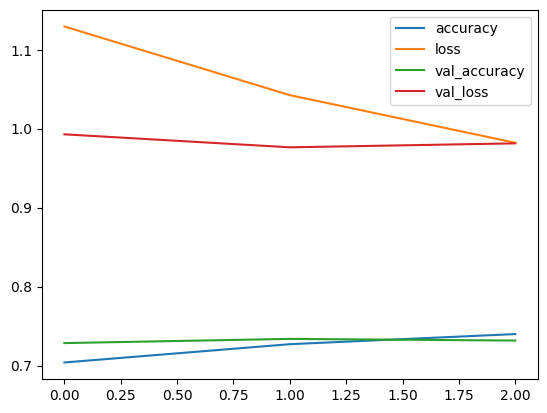

In [56]:
import pandas as pd
pd.DataFrame(history_0.history).plot()